**SNN Basics**

**Define Single Neuron Model For NPU(Neuromorphic Processing Unit SNN)**

In [214]:
# Spiking Neuron Model
# Define inputs, weights for inputs, decay constant, firing threshold

class Spike_neuron():
    def __init__(self, weights, decay_c, fire_thresh, cooldown_thresh):
        self.potential = 0                      # Current Potential in the Neuron Body
        self.weights = weights                  # Weights for each input from previous layer
        self.decay_c = decay_c                  # Decay constant which represents how fast the potential drops back to resting
        self.fire_thresh = fire_thresh          # Threshold at which the neuron fires to the next neurons in the next layer
        self.output = 0                         # Output signal of this neuron(firing signal)
        self.cooldown_thresh = cooldown_thresh  # Cooldown timer, usually brain neurons after firing have a set period for which they cannot fire
        self.counter = 0                        # The counter to enforce this timing delay between subsequent spikes
        self.spike_input_corr = np.zeros(3)
    
    def accumulate(self, inputs):
        # If the neuron is in resting state(cooldown) then no inputs are recieved
        # If the neuron is accepting inputs then it is is the matrix product of the inputs with the weights to obtain a single value which is added and checked with potential
        # If the potential is high enough then se fire for this neuron
        if self.counter > 0:
            self.output = 0
            self.counter -= 1
        else:
            potential_gain = self.weights @ inputs.T
            self.potential += potential_gain
            if(self.potential >= self.fire_thresh):
                self.spike_input_corr += inputs[0]
                self.fire()
        self.decay()
    
    def decay(self):
        # At each time step, the neuron is constantly losing potential and returning to resting potential(0)
        self.potential = self.potential - self.decay_c * self.potential
    
    def fire(self):
        # Firing involves setting the output to 1, setting potential back to 0, and setting a counter for cooldown
        self.output = 1
        self.potential = np.array([0])
        self.counter = self.cooldown_thresh


**Second Step - Define a layer of neurons which is a level of abstraction higher than a single neuron**

In [194]:
class Spike_Layer():
    def __init__(self, num_neuron, weights_v, decay_c_v, fire_thresh_v, cooldown_thresh_v):
        self.num_neuron = num_neuron
        self.weights_v = weights_v
        self.decay_c_v = decay_c_v
        self.fire_thresh_v = fire_thresh_v
        self.cooldown_thresh_v = cooldown_thresh_v
        self.neuron_list = []

    def initialize_neurons(self):
        for i in range(self.num_neuron):
            self.neuron_list.append(Spike_neuron(self.weights_v[i], self.decay_c_v[i], self.fire_thresh_v[i], self.cooldown_thresh_v[i]))

    def signal_prop(self, input_v):
        for i in range(len(self.neuron_list)):
            self.neuron_list[i].accumulate(np.array([input_v[0]]))


In [216]:
class Spike_Prop_Layer():
    # This layer is the interconnection between SNN neuron layers which collects output from one layer and feeds it as inputs to the next
    def __init__(self, l1, l2):
        self.Layer_in = l1
        self.Layer_out = l2
        self.spike_prop = []
        self.freq_count = np.zeros(l1.num_neuron)
        self.percentage_spikes = np.zeros(l1.num_neuron)
        self.threshold_correction_v = np.zeros(l1.num_neuron)

    def output_collect(self):
        # Logic for collecting the output signals
        self.spike_prop = np.zeros(len(l1.neuron_list))
        for i in range(len(l1.neuron_list)):
            self.spike_prop[i] = l1.neuron_list[i].output
        return self.spike_prop
    
    def log_output_spike(self):
            for i in range(len(self.spike_prop)):
                self.freq_count[i] += self.spike_prop[i]

    def compute_percentage_spikes(self):
            total_spike = 0
            for i in range(len(self.freq_count)):
                total_spike += self.freq_count[i]
            for i in range(len(self.percentage_spikes)):
                self.percentage_spikes[i] = self.freq_count[i]/total_spike
    

In [196]:
class Output_Decision_Layer():
    def __init__(self, output_layer):
        self.output_layer = output_layer
        self.output_count = np.zeros(output_layer.num_neuron)
        self.percentage_spike = np.zeros(output_layer.num_neuron)

    def log_output_spike(self):
        for i in range(len(self.output_count)):
            self.output_count[i] += self.output_layer.neuron_list[i].output

    def predict_output(self):
        output = 0
        output_count = 0
        for i in range(len(self.output_count)):
            if(self.output_count[i] > output_count):
                output = i
                output_count = self.output_count[i]
        return output

    def compute_percentage_spikes(self):
        total_spike = 0
        for i in range(len(self.output_count)):
            total_spike += self.output_count[i]
        for i in range(len(self.percentage_spike)):
            self.percentage_spike[i] = self.output_count[i]/total_spike

In [231]:
def Training_Changes(connect_layers, output_layer, y):

    # Based on frequency of spikes(since we want the hidden layer neurons to be active, but also one should not be dominating)
    # We can train by basically deciding a range we want to keep activity of each neuron in(0.3-0.5) and then add a correction factor which has a sign based on how far away from this we are to change the thresholds
    # When we do tune the parameters, we need to multiply this correction factor by some alpha to get the actual change to the threshold
    for layer in connect_layers:
        print(f'percentage spike: {layer.percentage_spikes}')

        for i in range(len(layer.percentage_spikes)):
            if(layer.percentage_spikes[i] < 0.1):
                layer.threshold_correction_v[i] = layer.percentage_spikes[i] - 0.2
            elif(layer.percentage_spikes[i] > 0.8):
                layer.threshold_correction_v[i] = 0.9 - layer.percentage_spikes[i]
            else:
                layer.threshold_correction_v[i] = 0

    # - If so we increase the weight if not we decrease it, we can perform this for all of them and average the result because each neuron in a layer is connected to the others, but the individual weights also play into this
    # 4) Depending on if we made a right or wrong connection then we can update this fact, if we are correct, keep the values, if not then invert them and repeat this for all training examples so we converge to the average where we predict as best as possible
    # -> We need to calculate if we are right or wrong and by how much and that affects the direction of the changes
    # --> Creating a variable for measuring the direction and magnitude of the correct diagnosis(define a variable for the actual output, 1 for correct, 0 for wrong and then in the decision layer keep that value(we would then need to return this value and pass it in through the training conversion play))
    
    # Find the true class from the perfect(true) labelled solution vector
    true_class = -1
    print(f'y {y[0]} {len(y[0])}')
    for i in range(len(y[0])):
        if y[0][i] == 1:
            true_class = i
            break
    print(f'true_class {true_class}')
    # compute the loss as what is the deviation from how much we predicted the true class
    loss = 1-output_layer.percentage_spike[true_class]
    print(f'output_layer.percentage_spike[true_class] = {output_layer.percentage_spike[true_class]}')
    print(F'loss {loss}')
    ## NEXT STEPS
    # for output layer neurons we increase weight for neuron that corresponds to true label, and by a magnitude corresponding to the loss
    # for output layer neurons we decrease weight for neurons that were not the true class label
    for i in range(len(output_layer.output_layer.neuron_list)):
        if i == true_class:
            print(f"true class detected: {output_layer.output_layer.neuron_list[i].weights}, {np.abs(output_layer.output_layer.neuron_list[i].weights) * loss}")
            output_layer.output_layer.neuron_list[i].weights += np.abs(output_layer.output_layer.neuron_list[i].weights) * loss
        else:
            print(f"not true class: {output_layer.output_layer.neuron_list[i].weights}, {-1 * np.abs(output_layer.output_layer.neuron_list[i].weights) * loss}")
            output_layer.output_layer.neuron_list[i].weights -= np.abs(output_layer.output_layer.neuron_list[i].weights) * loss

    # for hidden layer neurons we look at what input lead to the spikes most frequently based on percentage and then inc/dec(or don't touch) weight based on that
    for neuron in connect_layer.Layer_in.neuron_list:
        total = 0
        for i in range(len(neuron.spike_input_corr)):
            total += neuron.spike_input_corr[i]
        print(f'total {total}')
        percentage_input_corr = np.zeros(len(neuron.spike_input_corr))
        for i in range(len(neuron.spike_input_corr)):
            percentage_input_corr[i] = neuron.spike_input_corr[i]/total
        print(f'percentage_input_corr {percentage_input_corr}')
        for i in range(len(percentage_input_corr)):
            if(percentage_input_corr[i] < 0.3):
                print(f'neuron weight <0.3 {neuron.weights[i]}')
                neuron.weights[i] -= (1-percentage_input_corr[i])
                print(f"neuron weight after <0.3 {neuron.weights[i]}")
            elif(percentage_input_corr[i] > 0.5):
                print(f'neuron weight >0.5 {neuron.weights[i]}')
                neuron.weights[i] += (1-percentage_input_corr[i])
                print(f"neuron weight after >0.5 {neuron.weights[i]}")
            else:
                print(f"neuron weight same {neuron.weights[i]}")
                neuron.weights[i] = neuron.weights[i]
                print(f"neuron weight same after {neuron.weights[i]}")

# Plotting and Testing Codes

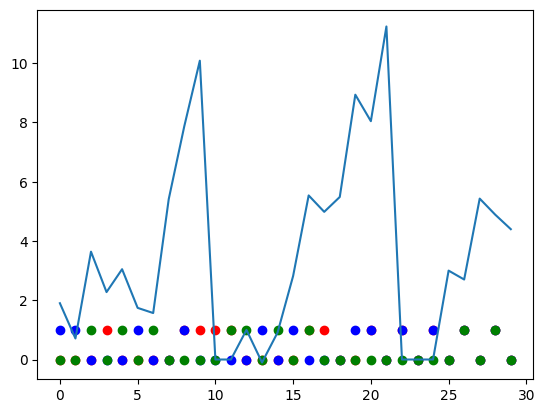

In [179]:
import numpy as np
import matplotlib.pyplot as plt

# Single Input to neuron mapped

weights = [3, 1, -1]
decay_c = 0.1
fire_thresh = 10
cooldown_thresh = 2

n1 = Spike_neuron(weights, decay_c, fire_thresh, cooldown_thresh)

input1 = [0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,0, 1, 0, 1, 0]
input2 = [1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,0, 1, 0, 1, 0]
input3 = [0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,0, 1, 0, 1, 0]

potentials = []
for i in range(len(input1)):
    n1.accumulate(np.array([[input1[i], input2[i], input3[i]]]))
    potentials.append(n1.potential)

x_s = np.arange(0,len(potentials), 1)

plt.plot(x_s, potentials)
plt.scatter(x_s, input1, c='red')
plt.scatter(x_s, input2, c='blue')
plt.scatter(x_s, input3, c='green')

In [182]:
# Spike Layer Probing/Testing

weights = [[3], [2], [1]]
decay_c = [0.1, 0.2, 0.05]
fire_thresh = [10, 5, 6]
cooldown_thresh = [2, 1, 3]

input1 = [0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,0, 1, 0, 1, 0]
l1 = Spike_Layer(3, weights, decay_c, fire_thresh, cooldown_thresh)
l1.initialize_neurons()

potentials_1 = []
potentials_2 = []
potentials_3 = []

for i in range(len(input1)):
    l1.signal_prop(np.array([[input1[i]]]))
    potentials_1.append(l1.neuron_list[0].potential)
    potentials_2.append(l1.neuron_list[1].potential)
    potentials_3.append(l1.neuron_list[2].potential)
    

x_s = np.arange(0,len(potentials_1), 1)

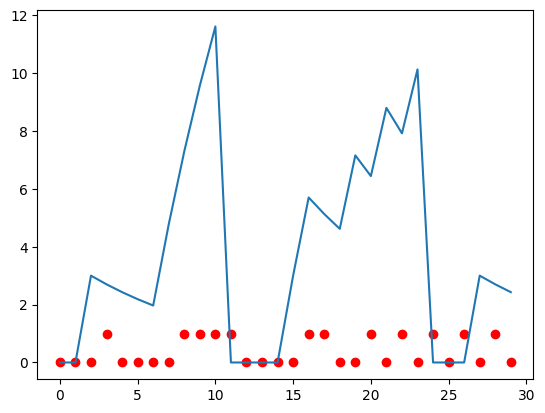

In [183]:
plt.plot(x_s, potentials_1)
input_plt_1 = []
for i in range(len(input1)):
    input_plt_1.append(input1[i])
plt.scatter(x_s, input_plt_1, c='red')

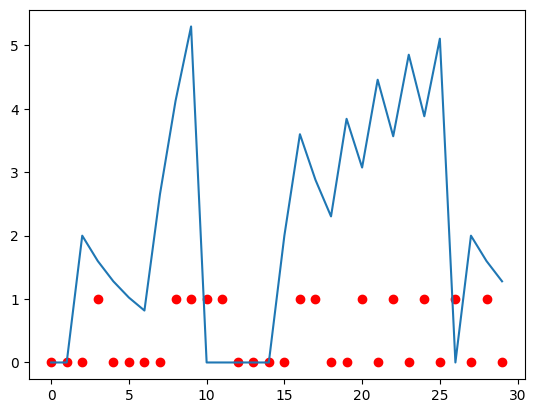

In [184]:
plt.plot(x_s, potentials_2)
input_plt_2 = []
for i in range(len(input1)):
    input_plt_2.append(input1[i])
plt.scatter(x_s, input_plt_2, c='red')

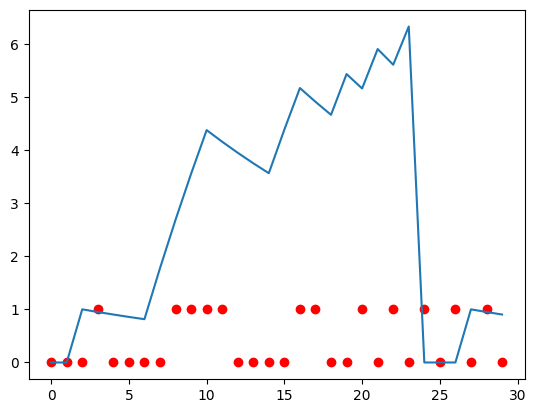

In [185]:
plt.plot(x_s, potentials_3)
input_plt_3 = []
for i in range(len(input1)):
    input_plt_3.append(input1[i])
plt.scatter(x_s, input_plt_3, c='red')

**Multi-Layer Neuron Feed-Forward(Spike Propogations)**

In [232]:
weights = [[[3, 3, 3], [2, 2, 2], [1, 1, 1]], [[1, 1, 1], [3, 3, 3], [-1, -1, 3]]]
decay_c = [[0.1, 0.2, 0.05], [0.1, 0.1, 0.1]]
fire_thresh = [[10, 5, 6], [11, 6, 3]]
cooldown_thresh = [[1, 1, 1], [1, 1, 1]]

input1 = [[0,0,0], [0,0,0], [0,0,0], [1,1,1], [0,0,0], [0,0,0], [0,0,0], [0,0,0], [1,1,1], [1,1,1], [1,1,1], [1,1,1], [0,0,0], [0,0,0], [0,0,0], [0,0,0], [1,1,1], [1,1,1], [0,0,0], [0,0,0], [1,1,1], [0,0,0], [1,1,1], [0,0,0], [1,1,1],[0,0,0], [1,1,1], [0,0,0], [1,1,1], [0,0,0]]
input2 = []
y = [[0,0,1]]

l1 = Spike_Layer(3, weights[0], decay_c[0], fire_thresh[0], cooldown_thresh[0])
l1.initialize_neurons()
l2 = Spike_Layer(3, weights[1], decay_c[1], fire_thresh[1], cooldown_thresh[1])
l2.initialize_neurons()

connect_layer = Spike_Prop_Layer(l1, l2)
decision_layer = Output_Decision_Layer(l2)

potentials_1 = []
potentials_2 = []
potentials_3 = []

potentials_1_2 = []
potentials_2_2 = []
potentials_3_2 = []

for i in range(len(input1)):
    l1.signal_prop(np.array([input1[i]]))
    potentials_1.append(l1.neuron_list[0].potential)
    potentials_2.append(l1.neuron_list[1].potential)
    potentials_3.append(l1.neuron_list[2].potential)
    input2.append(connect_layer.output_collect())
    connect_layer.log_output_spike()

for i in range(len(input2)):
    l2.signal_prop([input2[i]])
    potentials_1_2.append(l2.neuron_list[0].potential)
    potentials_2_2.append(l2.neuron_list[1].potential)
    potentials_3_2.append(l2.neuron_list[2].potential)
    decision_layer.log_output_spike()

connect_layer.compute_percentage_spikes()
decision_layer.compute_percentage_spikes()

x_s = np.arange(0,len(potentials_1_2), 1)

print(decision_layer.predict_output())
print(decision_layer.output_count)

Training_Changes([connect_layer], decision_layer, y)


1
[0. 5. 0.]
percentage spike: [0.29411765 0.52941176 0.17647059]
y [0, 0, 1] 3
true_class 2
output_layer.percentage_spike[true_class] = 0.0
loss 1.0
not true class: [1, 1, 1], [-1. -1. -1.]
not true class: [3, 3, 3], [-3. -3. -3.]
true class detected: [-1, -1, 3], [1. 1. 3.]
total 15.0
percentage_input_corr [0.33333333 0.33333333 0.33333333]
neuron weight same 3
neuron weight same after 3
neuron weight same 3
neuron weight same after 3
neuron weight same 3
neuron weight same after 3
total 27.0
percentage_input_corr [0.33333333 0.33333333 0.33333333]
neuron weight same 2
neuron weight same after 2
neuron weight same 2
neuron weight same after 2
neuron weight same 2
neuron weight same after 2
total 9.0
percentage_input_corr [0.33333333 0.33333333 0.33333333]
neuron weight same 1
neuron weight same after 1
neuron weight same 1
neuron weight same after 1
neuron weight same 1
neuron weight same after 1


[array([0.]), array([0.]), array([1.]), array([0.9]), array([0.81]), array([0.729]), array([0.6561]), array([2.59049]), array([3.331441]), array([3.9982969]), array([3.59846721]), array([3.23862049]), array([2.91475844]), array([2.6232826]), array([2.36095434]), array([4.1248589]), array([3.71237301]), array([3.34113571]), array([3.00702214]), array([4.70631993]), array([4.23568793]), array([5.81211914]), array([5.23090723]), array([5.7078165]), array([5.13703485]), array([5.62333137]), array([5.06099823]), array([7.55489841]), array([6.79940857]), array([6.11946771])]


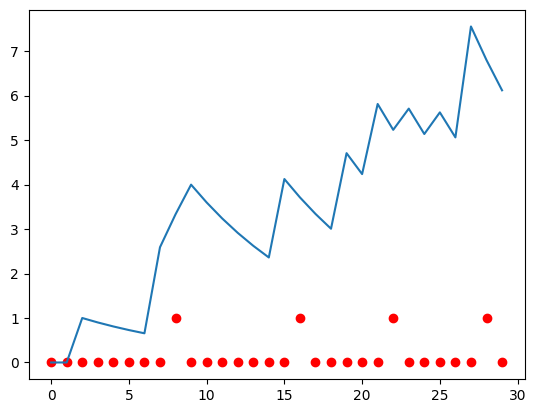

In [173]:
print(potentials_1_2)
plt.plot(x_s, potentials_1_2)
input_plt_1_2 = []
for i in range(len(input2)):
    input_plt_1_2.append(input2[i][0])
plt.scatter(x_s, input_plt_1_2, c='red')

[array([0.]), array([0.]), array([3.]), array([2.7]), array([2.43]), array([2.187]), array([1.9683]), array([7.77147]), array([0.]), array([3.]), array([2.7]), array([2.43]), array([2.187]), array([1.9683]), array([1.77147]), array([7.594323]), array([0.]), array([0.]), array([0.]), array([6.]), array([0.]), array([6.]), array([0.]), array([3.]), array([2.7]), array([5.43]), array([4.887]), array([13.3983]), array([0.]), array([0.])]


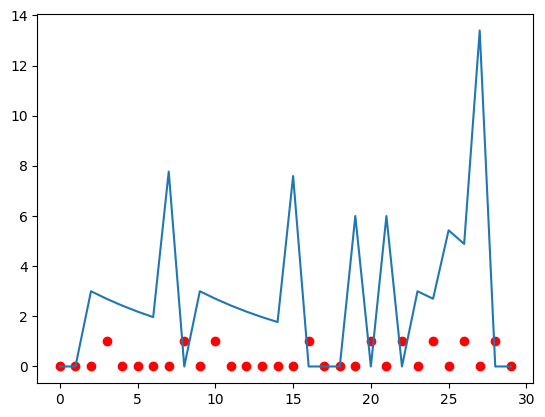

In [174]:
print(potentials_2_2)
plt.plot(x_s, potentials_2_2)
input_plt_2_2 = []
for i in range(len(input2)):
    input_plt_2_2.append(input2[i][1])
plt.scatter(x_s, input_plt_2_2, c='red')

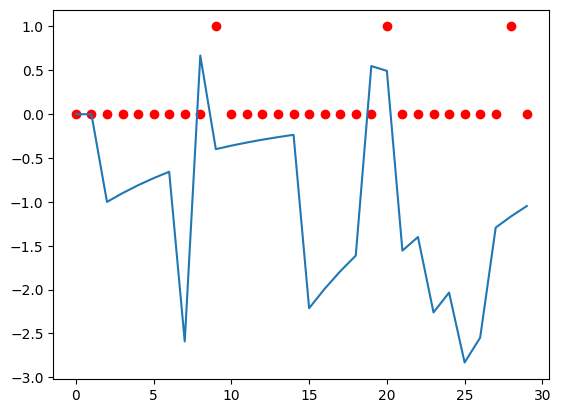

In [175]:
plt.plot(x_s, potentials_3_2)
input_plt_3_2 = []
for i in range(len(input2)):
    input_plt_3_2.append(input2[i][2])
plt.scatter(x_s, input_plt_3_2, c='red')